This notebook contains some code snippets that might be useful to start with, but no major code.

In [18]:
import dacepy as dp
import inspect
import matplotlib.pyplot as plt
import xarray as xr

# An original observation file

In [19]:
ds = xr.open_dataset("../../data/hackathon_data/wind_lidar/profiles_20250629_sIOP7/kitcube/WLS200s_115_20250629_600s_100m_wind_profile.nc")
print(ds.time.values)
ds

['2025-06-29T00:10:00.000000000' '2025-06-29T00:20:00.000000000'
 '2025-06-29T00:30:00.000000000' '2025-06-29T00:40:00.000000000'
 '2025-06-29T00:50:00.000000000' '2025-06-29T01:00:00.000000000'
 '2025-06-29T01:10:00.000000000' '2025-06-29T01:20:00.000000000'
 '2025-06-29T01:30:00.000000000' '2025-06-29T01:40:00.000000000'
 '2025-06-29T01:50:00.000000000' '2025-06-29T02:00:00.000000000'
 '2025-06-29T02:10:00.000000000' '2025-06-29T02:20:00.000000000'
 '2025-06-29T02:30:00.000000000' '2025-06-29T02:40:00.000000000'
 '2025-06-29T02:50:00.000000000' '2025-06-29T03:00:00.000000000'
 '2025-06-29T03:10:00.000000000' '2025-06-29T03:20:00.000000000'
 '2025-06-29T03:30:00.000000000' '2025-06-29T03:40:00.000000000'
 '2025-06-29T03:50:00.000000000' '2025-06-29T04:00:00.000000000'
 '2025-06-29T04:10:00.000000000' '2025-06-29T04:20:00.000000000'
 '2025-06-29T04:30:00.000000000' '2025-06-29T04:40:00.000000000'
 '2025-06-29T04:50:00.000000000' '2025-06-29T05:00:00.000000000'
 '2025-06-29T05:10:00.000

<xarray.Dataset> Size: 680kB
Dimensions:                            (time: 144, height: 51, nv: 2)
Coordinates:
  * time                               (time) datetime64[ns] 1kB 2025-06-29T0...
  * height                             (height) float64 408B 0.0 100.0 ... 5e+03
Dimensions without coordinates: nv
Data variables: (12/20)
    u                                  (time, height) float64 59kB ...
    v                                  (time, height) float64 59kB ...
    w                                  (time, height) float64 59kB ...
    var                                (time, height) float64 59kB ...
    cnr_sel_median                     (time, height) float64 59kB ...
    doppler_spectrum_width_sel_median  (time, height) float64 59kB ...
    ...                                 ...
    wspeed                             (time, height) float64 59kB ...
    time_bnds                          (time, nv) datetime64[ns] 2kB ...
    height_bnds                        (height, nv) float64 816B ...
    lat                                float64 8B ...
    lon                                float64 8B ...
    zsl                                float64 8B ...
Attributes: (12/37)
    station_name:                                       Sarnthein
    latitude:                                           46.634911
    longitude:                                          11.359278
    altitude:                                           986.0
    device_name:                                        WLS200s_115
    device_id:                                          https://hdl.handle.ne...
    ...                                                 ...
    AtmoProKIT_module_chain:                            elevation_filter_fg (...
    creation_date:                                      2025-10-17T17:33:02.0...
    time_coverage_duration:                             86400s
    time_coverage_resolution:                           600s
    time_coverage_start:                                2025-06-29T00:00:00
    time_coverage_end:                                  2025-06-30T00:00:00

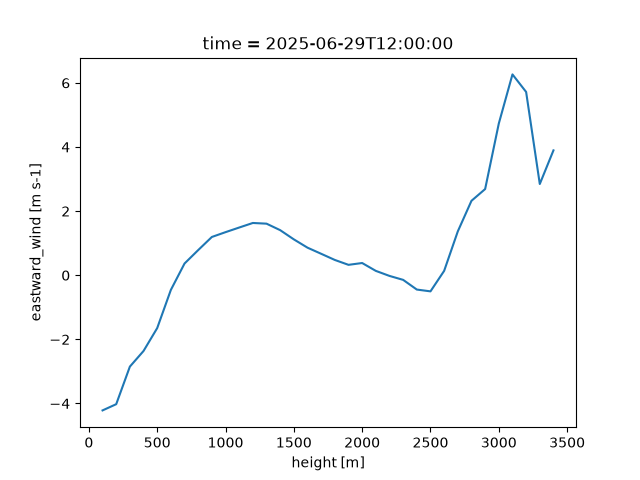

In [20]:
plt.figure()
ds.sel(time="2025-06-29T12:00:00")["u"].plot()
plt.show()

# A feedback file

In [21]:
ds_feedback = xr.open_dataset("../../results/rof_files/TEAMX_DL_fdbk_20250629_00.nc")
print(ds_feedback["varno"].values) # 3=u; 4=v
print(ds_feedback["level"].values) # height above sea level
print(ds_feedback.time.values)
ds_feedback

[3. 4. 3. ... 4. 3. 4.]
[ 666.  666.  766. ... 3602. 3702. 3702.]
[10. 20. 30. 40. 50. 60. 10. 20. 30. 40. 50. 60. 10. 20. 30. 40. 50. 60.
 10. 20. 30. 40. 50. 60. 10. 20. 30. 40. 50. 60. 10. 20. 30. 40. 50. 60.
 10. 20. 30. 40. 50. 60.]


<xarray.Dataset> Size: 49kB
Dimensions:    (d_hdr: 42, d_body: 2330, d_veri: 0)
Coordinates:
  * d_veri     (d_veri) float64 0B 
Dimensions without coordinates: d_hdr, d_body
Data variables: (12/15)
    i_body     (d_hdr) float64 336B ...
    l_body     (d_hdr) float32 168B ...
    n_level    (d_hdr) float32 168B ...
    obstype    (d_hdr) float32 168B ...
    codetype   (d_hdr) float32 168B ...
    statid     (d_hdr) |S10 420B ...
    ...         ...
    z_station  (d_hdr) float64 336B ...
    varno      (d_body) float32 9kB 3.0 4.0 3.0 4.0 3.0 ... 4.0 3.0 4.0 3.0 4.0
    obs        (d_body) float32 9kB ...
    level      (d_body) float32 9kB 666.0 666.0 766.0 ... 3.702e+03 3.702e+03
    level_typ  (d_body) float32 9kB ...
    level_sig  (d_body) float32 9kB ...
Attributes:
    verification_ref_date:  20250629
    verification_ref_time:  0
    n_hdr:                  42
    n_body:                 2330
    institution:            
    title:                  
    history:                2026-06-29 15:53:16.973887 dacepy FeedbackFile.to...
    source:                 dacepy 0.1
    file_version_number:     1.02
    n_radar:                0
    verification_start:     0
    verification_end:       0

In [22]:
# raw data: time counts 1 variables for 1 station every 10 min for 24 h = 144
# feedback data: time counts 1 variables for 7 stations every 10 min for 1 h = 42
len(ds.time.values), len(ds_feedback.time.values)

(144, 42)

# Using dacepy's feedback file class
to access an existing feedback file (ROF).

In [23]:
fdbkfile = "../../results/rof_files/TEAMX_DL_fdbk_20250629_00.nc"
fdbk = dp.read_fdbk(fdbkfile)
fdbk

<dacepy.fdbk.FeedbackFile>

Data:
<xarray.Dataset> Size: 34kB
Dimensions:    (d_hdr: 42, d_body: 2330)
Coordinates:
    l_body     (d_hdr) int16 84B ...
    obstype    (d_hdr) int8 42B 6 6 6 6 6 6 6 6 6 6 6 ... 6 6 6 6 6 6 6 6 6 6 6
    codetype   (d_hdr) int16 84B ...
    lat        (d_hdr) float32 168B ...
    lon        (d_hdr) float32 168B ...
    time       (d_hdr) datetime64[us] 336B 2025-06-29T00:10:00 ... 2025-06-29...
    varno      (d_body) int16 5kB ...
    level      (d_body) float32 9kB ...
Dimensions without coordinates: d_hdr, d_body
Data variables:
    i_body     (d_hdr) int32 168B 1 41 79 117 157 ... 2041 2099 2157 2215 2273
    n_level    (d_hdr) int16 84B ...
    statid     (d_hdr) |S10 420B ...
    z_station  (d_hdr) int32 168B ...
    obs        (d_body) float32 9kB ...
    level_typ  (d_body) int16 5kB ...
    level_sig  (d_body) int16 5kB ...
Attributes:
    verification_ref_date:  20250629
    verification_ref_time:  0
    n_hdr:                  42
    n_body: 

# Inspect dacepy's plotting functionality

In [24]:
for name, obj in inspect.getmembers(dp):
    if inspect.isfunction(obj) or inspect.isbuiltin(obj):
        print("=" * 80)
        print(name)

    try:
        print("Signature:", inspect.signature(obj))
    except (TypeError, ValueError):
        print("Signature: unavailable")

    doc = inspect.getdoc(obj)
    if doc:
        print("Description:")
        print(doc.split("\n\n")[0])  # first paragraph only
    else:
        print("Description: No docstring available")


Signature: unavailable
Description:
Built-in immutable sequence.
Signature: unavailable
Description:
dict() -> new empty dictionary
dict(mapping) -> new dictionary initialized from a mapping object's
    (key, value) pairs
dict(iterable) -> new dictionary initialized as if via:
    d = {}
    for k, v in iterable:
        d[k] = v
dict(**kwargs) -> new dictionary initialized with the name=value pairs
    in the keyword argument list.  For example:  dict(one=1, two=2)
Signature: unavailable
Description:
str(object='') -> str
str(bytes_or_buffer[, encoding[, errors]]) -> str
Signature: unavailable
Description:
str(object='') -> str
str(bytes_or_buffer[, encoding[, errors]]) -> str
Signature: unavailable
Description:
str(object='') -> str
str(bytes_or_buffer[, encoding[, errors]]) -> str
Signature: unavailable
Description:
Concrete implementation of SourceLoader using the file system.
Signature: unavailable
Description:
str(object='') -> str
str(bytes_or_buffer[, encoding[, errors]]) -> s

# Using dacepy's feedback file class for plotting
Dacepy comes with some plotting functionality. While it is likely very useful, we did not dive into the interpretation of these plots.

/mnt/c/Daten/2026-06_TeamX_workshop/git/dacepy/dacepy/fdbk/fdbk.py:174: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if (dataset.attrs['n_hdr'] != dataset.dims['d_hdr']
/mnt/c/Daten/2026-06_TeamX_workshop/git/dacepy/dacepy/fdbk/fdbk.py:175: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  or dataset.attrs['n_body'] != dataset.dims['d_body']):


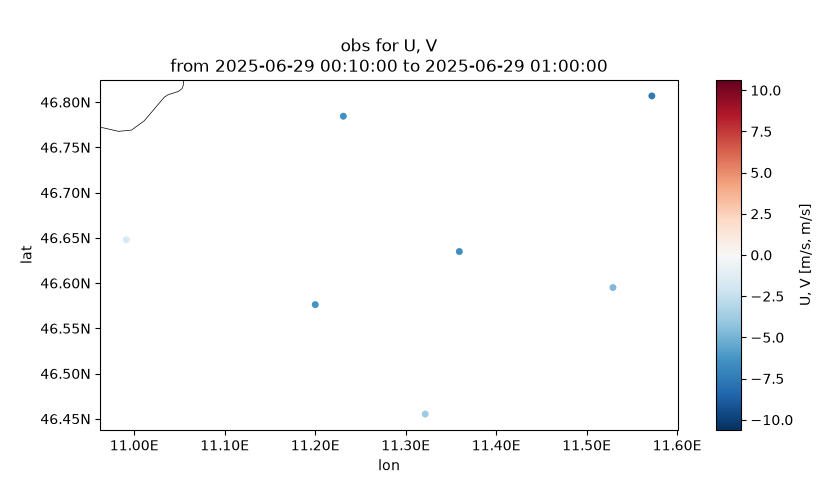

In [25]:
fdbk.scatter()

/mnt/c/Daten/2026-06_TeamX_workshop/git/dacepy/dacepy/fdbk/fdbk.py:174: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if (dataset.attrs['n_hdr'] != dataset.dims['d_hdr']
/mnt/c/Daten/2026-06_TeamX_workshop/git/dacepy/dacepy/fdbk/fdbk.py:175: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  or dataset.attrs['n_body'] != dataset.dims['d_body']):


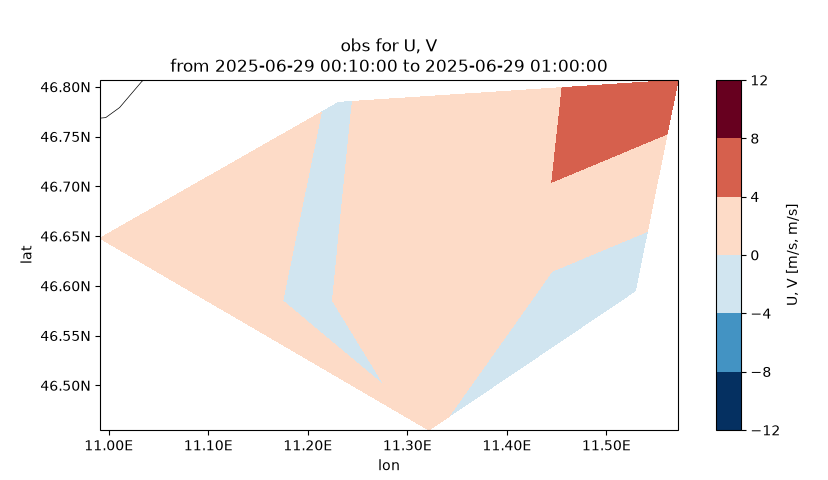

In [26]:
fdbk.contourf()

/mnt/c/Daten/2026-06_TeamX_workshop/git/dacepy/dacepy/fdbk/fdbk.py:174: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if (dataset.attrs['n_hdr'] != dataset.dims['d_hdr']
/mnt/c/Daten/2026-06_TeamX_workshop/git/dacepy/dacepy/fdbk/fdbk.py:175: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  or dataset.attrs['n_body'] != dataset.dims['d_body']):


<BarContainer object of 10 artists>

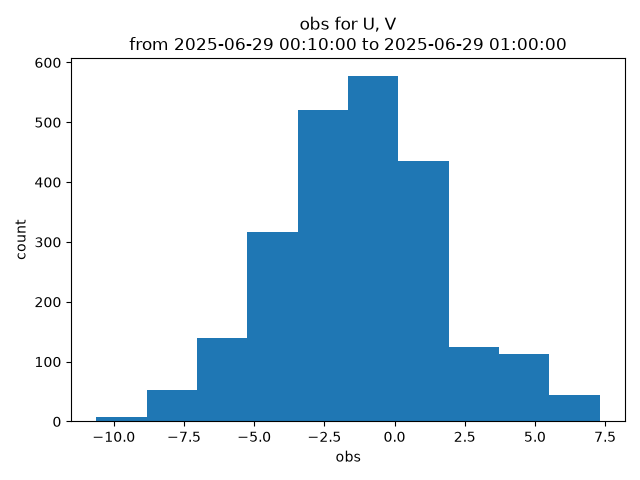

In [27]:
fdbk.hist()